In [1]:
import pandas as pd
import torch 
import matplotlib.pyplot as plt
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using {}'.format(device))
# data
df = pd.read_csv("Threespirals.csv", header=None, names=["x1", "x2", "y"])
df["y"] = df["y"] - 1

print("labels:", sorted(df["y"].unique()), "min/max:", df["y"].min(), df["y"].max())

X = torch.tensor(df[["x1","x2"]].values, dtype=torch.float32).to(device)
y = torch.tensor(df["y"].values, dtype=torch.long).to(device)


Using cuda
labels: [np.int64(0), np.int64(1), np.int64(2)] min/max: 0 2


In [2]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2,128),
    nn.Tanh(),
    nn.Linear(128, 128),
    nn.Tanh(),
    nn.Linear(128, 3)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [3]:
MAX_EPOCHS = 10000
LOSS_GOAL = 0.1
epoch = 0
losses = []
best_loss = float("inf")
start_time = time.perf_counter()

while best_loss > LOSS_GOAL and epoch < MAX_EPOCHS:
    optimizer.zero_grad()

    logits = model(X)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    loss_value = loss.item()
    losses.append(loss_value)

    if loss_value < best_loss:
        best_loss = loss_value

    if epoch % 100 == 0:
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            acc = (preds == y).float().mean().item()
        print(f"Epoch {epoch} | loss {loss_value:.4f} | acc {acc:.4f}")

    epoch += 1
    
if device == "cuda":
    torch.cuda.synchronize()

end_time = time.perf_counter()
print(f"Training took {end_time - start_time:.4f} seconds")

Epoch 0 | loss 1.1166 | acc 0.3397
Epoch 100 | loss 0.6495 | acc 0.7083
Epoch 200 | loss 0.5646 | acc 0.7212
Epoch 300 | loss 0.5276 | acc 0.7436
Epoch 400 | loss 0.5031 | acc 0.7340
Epoch 500 | loss 0.4840 | acc 0.7340
Epoch 600 | loss 0.4631 | acc 0.7404
Epoch 700 | loss 0.4444 | acc 0.7628
Epoch 800 | loss 0.4219 | acc 0.7724
Epoch 900 | loss 0.3986 | acc 0.7885
Epoch 1000 | loss 0.3662 | acc 0.8205
Epoch 1100 | loss 0.3320 | acc 0.8301
Epoch 1200 | loss 0.3036 | acc 0.8654
Epoch 1300 | loss 0.2724 | acc 0.8910
Epoch 1400 | loss 0.2396 | acc 0.9103
Epoch 1500 | loss 0.2155 | acc 0.9167
Epoch 1600 | loss 0.1886 | acc 0.9359
Epoch 1700 | loss 0.1710 | acc 0.9551
Epoch 1800 | loss 0.1577 | acc 0.9487
Epoch 1900 | loss 0.1376 | acc 0.9712
Epoch 2000 | loss 0.1303 | acc 0.9647
Epoch 2100 | loss 0.1055 | acc 0.9904
Training took 3.5608 seconds


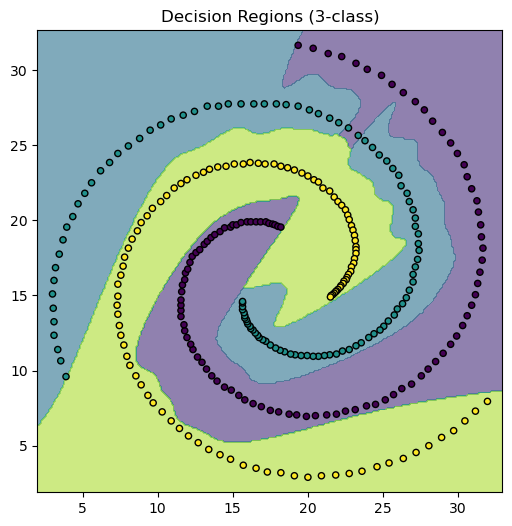

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Create grid of points
x_min, x_max = X[:,0].min().item() - 1, X[:,0].max().item() + 1
y_min, y_max = X[:,1].min().item() - 1, X[:,1].max().item() + 1

res = 800

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()],
    dtype=torch.float32,
    device=device
)

# Predict class for each grid point
with torch.no_grad():
    logits = model(grid)                 # (90000, 3)
    preds = torch.argmax(logits, dim=1)  # (90000,)
    Z = preds.reshape(xx.shape).cpu().numpy()

# Plot class regions + points
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, levels=3, alpha=0.6)
plt.scatter(X[:,0].cpu(), X[:,1].cpu(), c=y.cpu(), edgecolors='k', s=20)
plt.title("Decision Regions (3-class)")
plt.show()

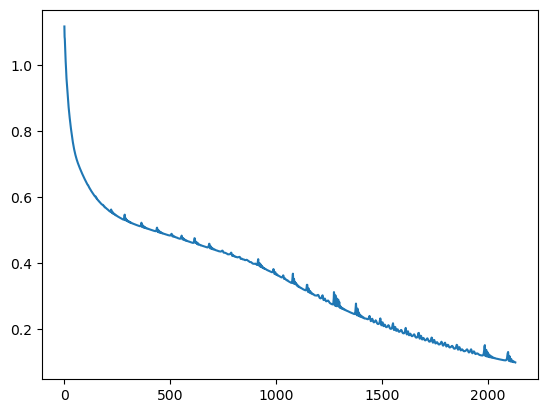

In [5]:
plt.plot(losses)
plt.show()